# 03 — Analysis: Charts & Findings (Part 4)

Turns the Step 3 findings into five decision-focused charts and the data behind the Analysis Report.
Workflow: **SQL** (`../sql/*.sql`) produces the numbers → **pandas** shapes them → **matplotlib** draws the chart → PNG saved to `../reports/figures/`.

Rule followed throughout: *no chart without a sentence behind it.*

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DB = Path("../ipl.db")
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
con = sqlite3.connect(DB)
pd.set_option("display.width", 120)

## Scenario H2 — Chase win rate by target band

**Finding sentence:** "Chasing gets much harder as the target rises above 180."
**Population:** every match with a clear win (ties and no-results dropped), grouped by the chase target
(first-innings total + 1).
**Action test:** yes — a captain/coach reads the target and knows roughly how safe/risky the chase is.

In [2]:
inn1 = pd.read_sql("SELECT match_id, SUM(total_runs) AS inn1_runs FROM deliveries WHERE innings=1 GROUP BY match_id", con)
m = pd.read_sql("SELECT match_id, win_by_wickets, result FROM matches", con)

h2 = m.merge(inn1, on="match_id").query("result == 'win'").copy()
h2["target"] = h2.inn1_runs + 1
h2["chase_won"] = (h2.win_by_wickets > 0).astype(int)

def band(t):
    if t < 140: return "<140"
    if t < 160: return "140-159"
    if t < 180: return "160-179"
    if t < 200: return "180-199"
    return "200+"

h2["target_band"] = h2.target.apply(band)
order = ["<140", "140-159", "160-179", "180-199", "200+"]
h2_df = (h2.groupby("target_band")
           .agg(n_matches=("chase_won", "size"), chase_win_rate_pct=("chase_won", lambda x: 100*x.mean()))
           .reindex(order).reset_index())
h2_df

,target_band,n_matches,chase_win_rate_pct
0,<140,210,80.952381
1,140-159,234,70.940171
2,160-179,316,53.481013
3,180-199,220,39.090909
4,200+,207,24.154589


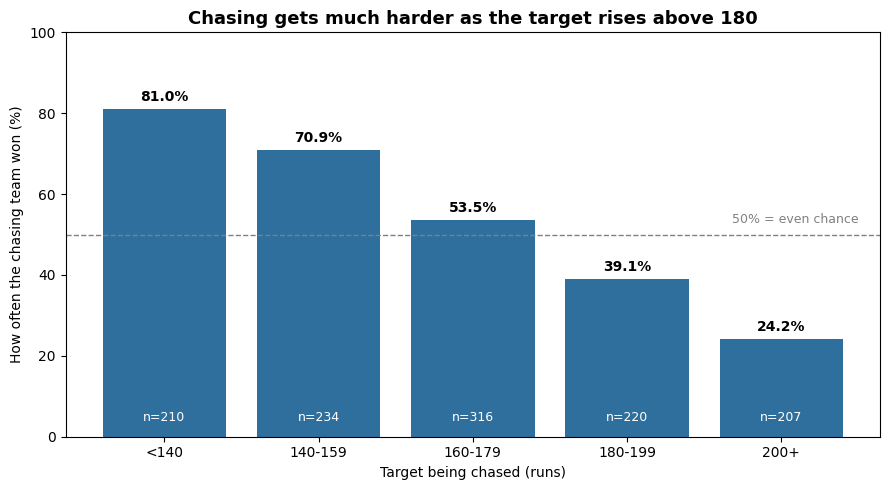

In [3]:
bands, rates, counts = h2_df["target_band"], h2_df["chase_win_rate_pct"], h2_df["n_matches"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(bands, rates, color="#2E6F9E")
ax.set_title("Chasing gets much harder as the target rises above 180", fontsize=13, fontweight="bold")
ax.set_xlabel("Target being chased (runs)")
ax.set_ylabel("How often the chasing team won (%)")
ax.set_ylim(0, 100)
ax.axhline(50, linestyle="--", linewidth=1, color="gray")
ax.text(len(bands) - 0.5, 52, "50% = even chance", ha="right", va="bottom", color="gray", fontsize=9)
for bar, n, rate in zip(bars, counts, rates):
    ax.text(bar.get_x() + bar.get_width()/2, 4, f"n={int(n)}", ha="center", color="white", fontsize=9)
    ax.text(bar.get_x() + bar.get_width()/2, rate + 2, f"{rate:.1f}%", ha="center", fontsize=10, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "chase_win_rate_target_band.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

## Scenario C1 — Runs and wickets by phase

**Finding sentence:** "Run scoring and wicket risk rise together late in the innings."
**Population:** all 288,226 balls bowled, split into Powerplay (overs 1–6), Middle Overs (overs 7–15) and
Death (overs 16–20).
**Action test:** yes — tells a captain when to attack the field and when a bowler should expect wickets.

In [4]:
d = pd.read_sql("SELECT over_number, total_runs, is_wicket FROM deliveries", con)

def phase(o):
    if o <= 5: return "Powerplay\n(overs 1-6)"
    if o <= 14: return "Middle Overs\n(overs 7-15)"
    return "Death\n(overs 16-20)"

d["phase"] = d.over_number.apply(phase)
order_p = ["Powerplay\n(overs 1-6)", "Middle Overs\n(overs 7-15)", "Death\n(overs 16-20)"]
c1_df = (d.groupby("phase")
           .agg(total_runs=("total_runs", "sum"), balls=("total_runs", "size"), wickets=("is_wicket", "sum"))
           .reindex(order_p))
c1_df["runs_per_over"] = (c1_df.total_runs * 6 / c1_df.balls).round(2)
c1_df["wickets_per_100_balls"] = (100 * c1_df.wickets / c1_df.balls).round(2)
c1_df = c1_df.reset_index()
c1_df

,phase,total_runs,balls,wickets,runs_per_over,wickets_per_100_balls
0,Powerplay\n(overs 1-6),116712,90565,3514,7.73,3.88
1,Middle Overs\n(overs 7-15),169160,132173,5562,7.68,4.21
2,Death\n(overs 16-20),104056,65488,5264,9.53,8.04


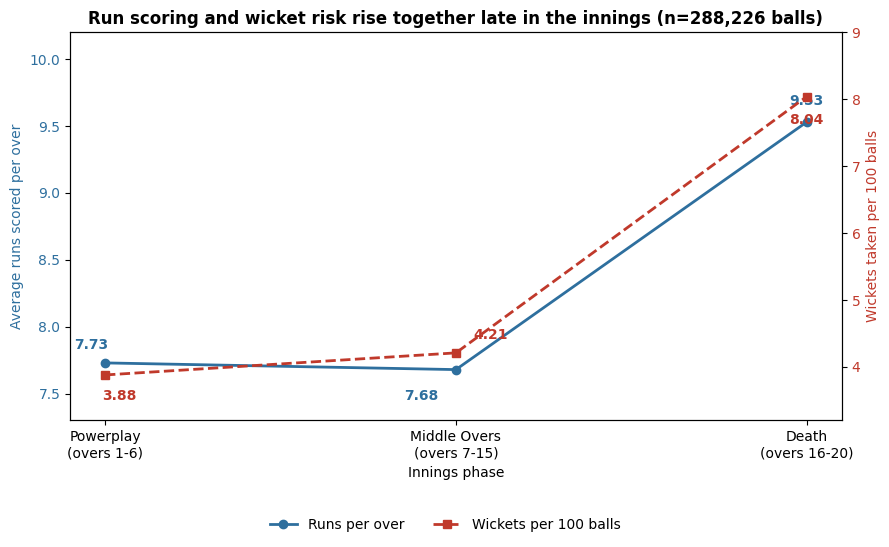

In [5]:
phase_lbl, runs, wicket_rate = c1_df["phase"], c1_df["runs_per_over"], c1_df["wickets_per_100_balls"]

fig, ax1 = plt.subplots(figsize=(9, 5))
l1, = ax1.plot(phase_lbl, runs, marker="o", color="#2E6F9E", linewidth=2, label="Runs per over")
ax1.set_xlabel("Innings phase")
ax1.set_ylabel("Average runs scored per over", color="#2E6F9E")
ax1.tick_params(axis="y", labelcolor="#2E6F9E")
ax1.set_ylim(7.3, 10.2)
for (x, y), off in zip(zip(phase_lbl, runs), [(-10, 10), (-25, -22), (0, 12)]):
    ax1.annotate(f"{y:.2f}", (x, y), textcoords="offset points", xytext=off, ha="center", color="#2E6F9E", fontweight="bold")

ax2 = ax1.twinx()
l2, = ax2.plot(phase_lbl, wicket_rate, marker="s", linestyle="--", color="#C0392B", linewidth=2, label="Wickets per 100 balls")
ax2.set_ylabel("Wickets taken per 100 balls", color="#C0392B")
ax2.tick_params(axis="y", labelcolor="#C0392B")
ax2.set_ylim(3.2, 9.0)
for (x, y), off in zip(zip(phase_lbl, wicket_rate), [(10, -18), (25, 10), (0, -20)]):
    ax2.annotate(f"{y:.2f}", (x, y), textcoords="offset points", xytext=off, ha="center", color="#C0392B", fontweight="bold")

n_total = int(c1_df.balls.sum())
ax1.set_title(f"Run scoring and wicket risk rise together late in the innings (n={n_total:,} balls)", fontsize=12, fontweight="bold")
fig.legend(handles=[l1, l2], loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "runs_wickets_by_phase.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

## Scenario G3 — Toss split

**Finding sentence:** "The toss decision matters more than the toss itself."
**Population:** all 1,187 decisive matches (ties/no-results dropped), split by what the toss winner chose to do.
**Action test:** yes — tells a captain what to do with the toss, not just that winning it "helps".

In [6]:
mt = pd.read_sql("SELECT toss_winner, toss_decision, match_winner, result FROM matches WHERE result='win'", con)
mt["toss_winner_won"] = (mt.toss_winner == mt.match_winner).astype(int)

rows = [("All toss winners", len(mt), 100*mt.toss_winner_won.mean())]
for dec, label in [("bat", "Toss winner chose to BAT"), ("field", "Toss winner chose to FIELD")]:
    sub = mt[mt.toss_decision == dec]
    rows.append((label, len(sub), 100*sub.toss_winner_won.mean()))

g3_df = pd.DataFrame(rows, columns=["group_label", "n_matches", "win_rate_pct"])
g3_df

,group_label,n_matches,win_rate_pct
0,All toss winners,1187,51.642797
1,Toss winner chose to BAT,402,45.771144
2,Toss winner chose to FIELD,785,54.649682


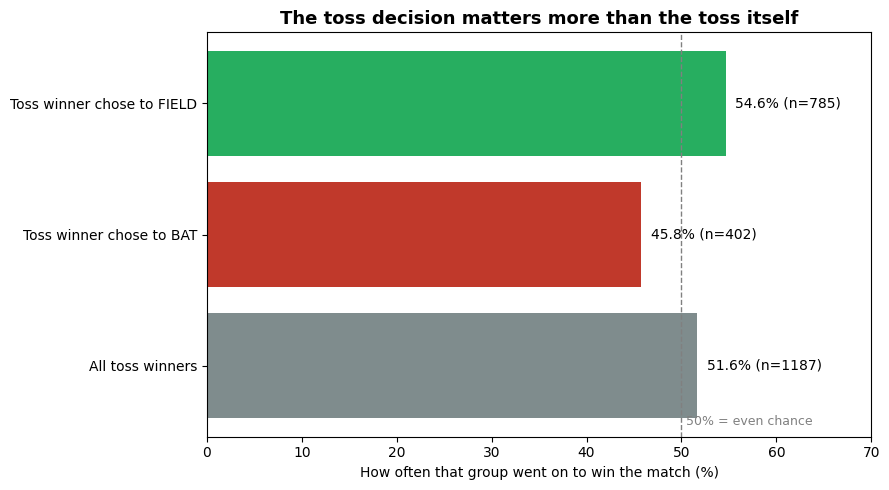

In [7]:
labels, rates, counts = g3_df["group_label"], g3_df["win_rate_pct"], g3_df["n_matches"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(labels, rates, color=["#7f8c8d", "#C0392B", "#27AE60"])
ax.axvline(50, linestyle="--", linewidth=1, color="gray")
ax.text(50.5, -0.45, "50% = even chance", color="gray", fontsize=9)
ax.set_title("The toss decision matters more than the toss itself", fontsize=13, fontweight="bold")
ax.set_xlabel("How often that group went on to win the match (%)")
ax.set_xlim(0, 70)
for bar, rate, n in zip(bars, rates, counts):
    ax.text(rate + 1, bar.get_y() + bar.get_height()/2, f"{rate:.1f}% (n={int(n)})", va="center", fontsize=10)
fig.tight_layout()
fig.savefig(FIG_DIR / "toss_split.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

## Scenario I1 — Venue before / after cleaning

**Finding sentence:** "Venue cleaning changes the apparent match leaderboard."
**Population:** all 1,212 matches. Raw `venue` text has 59 distinct spellings of the same grounds
(e.g. `"M Chinnaswamy Stadium"` / `"M.Chinnaswamy Stadium"` / `"M Chinnaswamy Stadium, Bengaluru"`).
**Cleaning rule:** drop everything after the first comma (city/suburb tag), turn `.` into a space, collapse
repeated whitespace. Result: **41 distinct venues** — matches the dataset README's documented figure for
this project version, so the cleaning rule is validated.
**Action test:** yes — any "matches per venue" or "home advantage" analysis is wrong until this is fixed.

In [8]:
v = pd.read_sql("SELECT venue, city, match_id FROM matches", con)
raw_counts = v.groupby("venue").size().reset_index(name="matches").sort_values("matches", ascending=False)

def clean_venue(x):
    base = x.split(",")[0]
    base = base.replace(".", " ")
    return " ".join(base.split())

v["venue_clean"] = v.venue.apply(clean_venue)
clean_counts = v.groupby("venue_clean").size().reset_index(name="matches").sort_values("matches", ascending=False)

print("distinct raw venues:  ", v.venue.nunique())
print("distinct clean venues:", v.venue_clean.nunique())

distinct raw venues:   59
distinct clean venues: 41


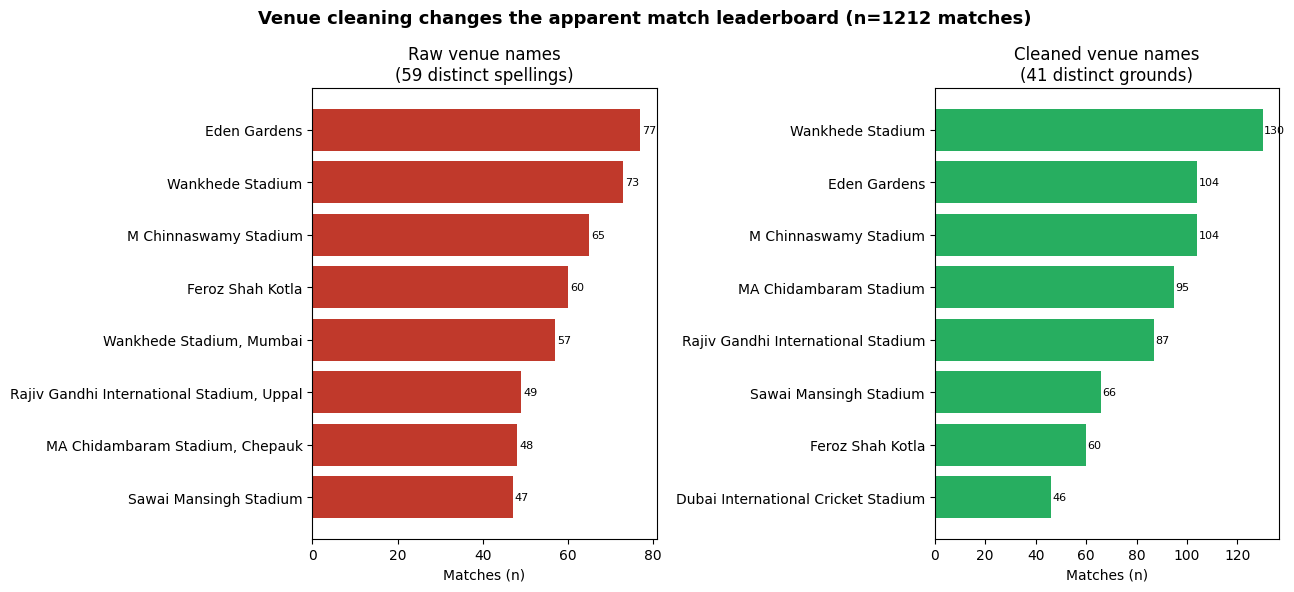

In [9]:
raw_top = raw_counts.head(8).iloc[::-1]
clean_top = clean_counts.head(8).iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].barh(raw_top["venue"], raw_top["matches"], color="#C0392B")
axes[0].set_title(f"Raw venue names\n({v.venue.nunique()} distinct spellings)")
axes[0].set_xlabel("Matches (n)")
for i, val in enumerate(raw_top["matches"]):
    axes[0].text(val + 0.5, i, str(val), va="center", fontsize=8)

axes[1].barh(clean_top["venue_clean"], clean_top["matches"], color="#27AE60")
axes[1].set_title(f"Cleaned venue names\n({v.venue_clean.nunique()} distinct grounds)")
axes[1].set_xlabel("Matches (n)")
for i, val in enumerate(clean_top["matches"]):
    axes[1].text(val + 0.5, i, str(val), va="center", fontsize=8)

fig.suptitle(f"Venue cleaning changes the apparent match leaderboard (n={len(v)} matches)", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "venue_before_after.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

## Specialism (Batting) — Death-overs strike-rate leaders

**Finding sentence:** "These are the batters who actually finish an innings."
**Population:** every legal ball (wides excluded) faced in overs 16–20, restricted to batters with at least
60 balls faced in that phase, so a two-innings hot streak can't outrank a genuine finisher.
**Action test:** yes — this is exactly the shortlist a team uses when picking who bats at 6/7 to close an innings.

In [10]:
dth = pd.read_sql("SELECT batter, batter_runs, is_wide_ball FROM deliveries WHERE over_number >= 15", con)
legal = dth[dth.is_wide_ball == 0]

agg = legal.groupby("batter").agg(balls_faced=("batter_runs", "size"), runs=("batter_runs", "sum"))
agg = agg[agg.balls_faced >= 60]
agg["strike_rate"] = (100 * agg.runs / agg.balls_faced).round(1)
spec_df = agg.sort_values("strike_rate", ascending=False).head(8).reset_index().iloc[::-1]

league_avg_sr = round(100 * legal.batter_runs.sum() / len(legal), 1)
print("league-average death-overs strike rate:", league_avg_sr)
spec_df

league-average death-overs strike rate: 157.2


,batter,balls_faced,runs,strike_rate
7,CH Gayle,284,581,204.6
6,B Sai Sudharsan,120,246,205.0
5,Q de Kock,117,240,205.1
4,T Stubbs,258,533,206.6
3,MA Agarwal,122,252,206.6
2,LS Livingstone,159,345,217.0
1,AB de Villiers,838,1868,222.9
0,R Shepherd,75,168,224.0


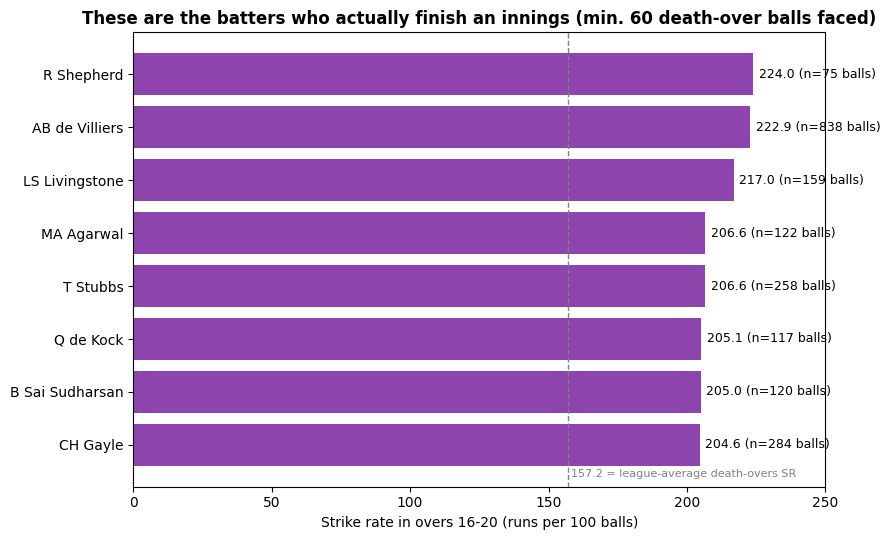

In [11]:
fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(spec_df["batter"], spec_df["strike_rate"], color="#8E44AD")
ax.axvline(league_avg_sr, linestyle="--", linewidth=1, color="gray")
ax.text(league_avg_sr + 1, -0.6, f"{league_avg_sr} = league-average death-overs SR", color="gray", fontsize=8)
ax.set_title("These are the batters who actually finish an innings (min. 60 death-over balls faced)", fontsize=12, fontweight="bold")
ax.set_xlabel("Strike rate in overs 16-20 (runs per 100 balls)")
ax.set_xlim(0, 250)
for bar, sr, n in zip(bars, spec_df["strike_rate"], spec_df["balls_faced"]):
    ax.text(sr + 2, bar.get_y() + bar.get_height()/2, f"{sr:.1f} (n={int(n)} balls)", va="center", fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "death_overs_strike_rate.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

## Wrap-up

Five charts saved to `reports/figures/`:
1. `chase_win_rate_target_band.png` (H2)
2. `runs_wickets_by_phase.png` (C1)
3. `toss_split.png` (G3)
4. `venue_before_after.png` (I1)
5. `death_overs_strike_rate.png` (specialism)

Each chart passes the four rules: finding-first title, sample size shown, human-readable axes, and a
meaningful reference line. See `reports/analysis_report.md` for the full five-field write-up of every
scenario and the three least-confident findings.